# **Proyecto final: Proporcionar sugerencias basadas en datos para RR.HH.**

## Descripción y entregables

Este proyecto final te brinda la oportunidad de analizar un conjunto de datos y crear modelos predictivos que aporten información al departamento de Recursos Humanos (RR. HH.) de una importante consultora.

Al finalizar, tendrás dos materiales que podrás presentar a futuros empleadores. Uno es un breve resumen de una página de este proyecto, que presentarás a las partes interesadas externas como profesional de datos en Salifort Motors. El otro es un cuaderno de código completo que se proporciona aquí. Considera tus cursos previos y selecciona una forma de abordar esta pregunta del proyecto. Utiliza un modelo de regresión o un modelo de aprendizaje automático para predecir si un empleado dejará la empresa. El ejemplo que sigue a esta actividad muestra ambos enfoques, pero solo necesitas uno.

En tus entregables, incluirás la evaluación del modelo (e interpretación, si corresponde), una o más visualizaciones de datos de tu elección directamente relacionadas con la pregunta que planteas, consideraciones éticas y los recursos que utilizaste para resolver problemas y encontrar respuestas o soluciones.

# **Etapas PACE**


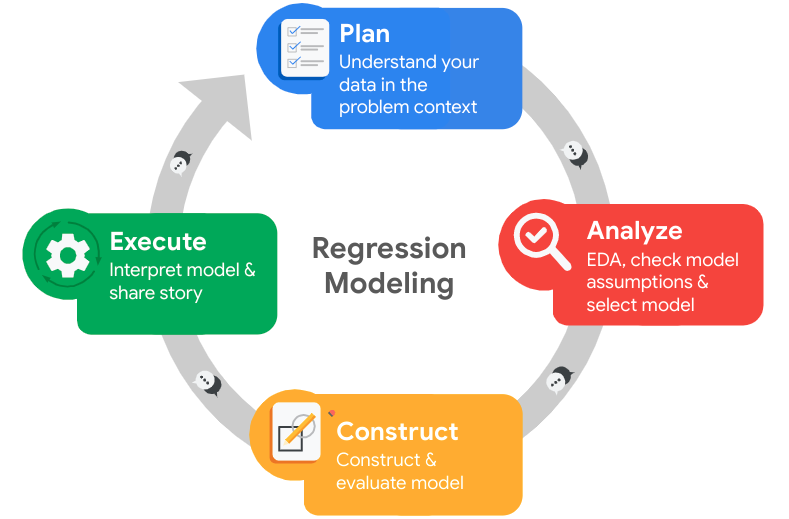

## **Pace: Plan**

Considere las preguntas de su Documento de Estrategia PACE para reflexionar sobre la etapa de planificación.

En esta etapa, considere lo siguiente:

### Comprender el escenario y el problema del negocio.

El departamento de RR. HH. de Salifort Motors quiere tomar iniciativas para mejorar la satisfacción de los empleados. Recopilaron datos de los empleados, pero ahora no saben qué hacer con ellos. Se refieren a usted como un profesional en análisis de datos y le piden que les brinde sugerencias basadas en su comprensión de los datos. Se plantean la siguiente pregunta: ¿qué es probable que haga que un empleado deje la empresa?

Sus objetivos en este proyecto son analizar los datos recopilados por el departamento de RR. HH. y crear un modelo que prediga si un empleado dejará la empresa o no.

Si puede predecir la probabilidad de que los empleados renuncien, podría identificar los factores que contribuyen a su salida. Dado que encontrar, entrevistar y contratar nuevos empleados es una tarea costosa y requiere mucho tiempo, aumentar la retención de personal será beneficioso para la empresa.

### Familiarícese con el conjunto de datos de RR.HH.

El conjunto de datos que utilizará en este laboratorio contiene 15 000 filas y 10 columnas para las variables que se enumeran a continuación.

**Nota:** No necesita descargar ningún dato para completar este laboratorio. Para obtener más información sobre los datos, consulte su fuente en [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |Descripción |
-----|-----|-----| 
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|Nivel de satisfacción laboral informado por los empleados|
last_evaluation|Score of employee's last performance review [0&ndash;1]|1Puntuación de la última evaluación de desempeño del empleado|
number_project|Number of projects employee contributes to|Número de proyectos a los que contribuye el empleado|
average_monthly_hours|Average number of hours employee worked per month|Número promedio de horas trabajadas por empleado al mes|
time_spend_company|How long the employee has been with the company (years)|Cuánto tiempo lleva el empleado en la empresa (años)|
Work_accident|Whether or not the employee experienced an accident while at work|Si el empleado sufrió o no un accidente mientras trabajaba|
left|Whether or not the employee left the company|Si el empleado abandonó o no la empresa|
promotion_last_5years|Whether or not the employee was promoted in the last 5 years|Si el empleado fue ascendido o no en los últimos 5 años|
Department|The employee's department|El departamento del empleado|
salary|The employee's salary (U.S. dollars)|El salario del empleado (dólares estadounidenses)|

💭
### Reflexione sobre estas preguntas a medida que completa la etapa de planificación.

* ¿Quiénes son las partes interesadas en este proyecto?
- ¿Qué intenta resolver o lograr?
- ¿Cuáles son sus observaciones iniciales al explorar los datos?
- ¿Qué recursos utiliza al completar esta etapa? (Asegúrese de incluir los enlaces).
- ¿Tiene alguna consideración ética en esta etapa?

[Haga doble clic para ingresar sus respuestas aquí.]

## Paso 1. Importaciones

* Importar paquetes
* Cargar conjunto de datos

### Importar paquetes

In [2]:
# Importar paquetes
### YOUR CODE HERE ### 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Cargar conjunto de datos

`Pandas` se utiliza para leer un conjunto de datos llamado **`HR_capstone_dataset.csv`.** Como se muestra en esta celda, el conjunto de datos se ha cargado automáticamente. No necesita descargar el archivo .csv ni proporcionar más código para acceder al conjunto de datos y continuar con este laboratorio. Continúe con esta actividad siguiendo las siguientes instrucciones.

In [3]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Cargar un conjunto de datos en un marco de datos
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Mostrar las primeras filas del marco de datos
### YOUR CODE HERE ###
df0.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## Paso 2. Exploración de datos (EDA inicial y limpieza de datos)

- Comprenda sus variables
- Limpie su conjunto de datos (datos faltantes, datos redundantes, valores atípicos)

### Recopilar información básica sobre los datos

In [4]:
# Recopilar información básica sobre los datos
### YOUR CODE HERE ###
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Recopilar estadísticas descriptivas sobre los datos

In [5]:
# Recopilar estadísticas descriptivas sobre los datos
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Cambiar el nombre de las columnas

Como paso de limpieza de datos, renombre las columnas según sea necesario. Estandarice los nombres de las columnas para que todos estén en formato `snake_case`, corrija los nombres de columna mal escritos y concéntrelos según sea necesario.

In [6]:
# Mostrar todos los nombres de las columnas
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Cambie el nombre de las columnas según sea necesario
### YOUR CODE HERE ###
df0.rename(columns={'Work_accident': 'work_accident', 'Department': 'department'}, inplace=1)

# Mostrar todos los nombres de columnas después de la actualización
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Comprobar valores faltantes

Verifique si faltan valores en los datos.

In [7]:
# Comprobar valores faltantes
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

### Verificar duplicados

Compruebe si hay entradas duplicadas en los datos.

In [8]:
# Buscar duplicados
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [9]:
# Inspeccione algunas filas que contengan duplicados según sea necesario
### YOUR CODE HERE ###
df0[df0.duplicated()].head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
1516,0.40,0.50,2,127,3,0,1,0,IT,low
1616,0.37,0.46,2,156,3,0,1,0,sales,low
1696,0.39,0.56,2,160,3,0,1,0,sales,low
1833,0.10,0.85,6,266,4,0,1,0,sales,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low


In [11]:
# Eliminar duplicados y guardar el marco de datos resultante en una nueva variable según sea necesario
### YOUR CODE HERE ###
df1 = df0.drop_duplicates()

# Mostrar las primeras filas del nuevo marco de datos según sea necesario
### YOUR CODE HERE ###
print(df1.shape)
print(df1.head(10))

(11991, 10)
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   
5                0.41             0.50               2                   153   
6                0.10             0.77               6                   247   
7                0.92             0.85               5                   259   
8                0.89             1.00               5                   224   
9                0.42             0.53               2                   142   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3      

### Comprobar valores atípicos

Comprobar si hay valores atípicos en los datos.

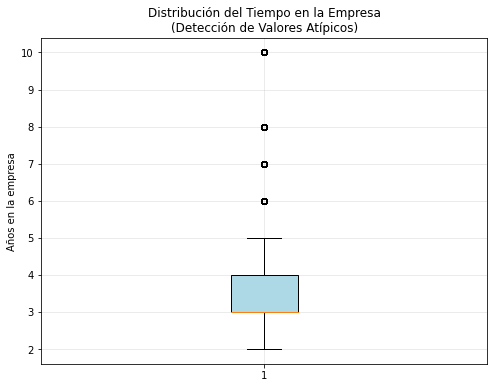

Estadísticas descriptivas de time_spend_company:
count    11991.000000
mean         3.364857
std          1.330240
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: time_spend_company, dtype: float64


In [13]:
# Cree un diagrama de caja para visualizar la distribución de la permanencia y detectar valores atípicos
### YOUR CODE HERE ###
# Diagrama de caja específico para detectar valores atípicos en time_spend_company
plt.figure(figsize=(8, 6))
box_plot = plt.boxplot(df1['time_spend_company'], patch_artist=True)
box_plot['boxes'][0].set_facecolor('lightblue')
plt.title('Distribución del Tiempo en la Empresa\n(Detección de Valores Atípicos)')
plt.ylabel('Años en la empresa')
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar estadísticas para identificar valores atípicos
print("Estadísticas descriptivas de time_spend_company:")
print(df1['time_spend_company'].describe())


In [22]:
print("permanencia = 10",df1[df1["time_spend_company"]==10].count())
print("permanencia = 8",df1[df1["time_spend_company"]==8].count())
print("permanencia = 7",df1[df1["time_spend_company"]==7].count())
print("permanencia = 6",df1[df1["time_spend_company"]==6].count())

permanencia = 10 satisfaction_level       107
last_evaluation          107
number_project           107
average_montly_hours     107
time_spend_company       107
work_accident            107
left                     107
promotion_last_5years    107
department               107
salary                   107
dtype: int64
permanencia = 8 satisfaction_level       81
last_evaluation          81
number_project           81
average_montly_hours     81
time_spend_company       81
work_accident            81
left                     81
promotion_last_5years    81
department               81
salary                   81
dtype: int64
permanencia = 7 satisfaction_level       94
last_evaluation          94
number_project           94
average_montly_hours     94
time_spend_company       94
work_accident            94
left                     94
promotion_last_5years    94
department               94
salary                   94
dtype: int64
permanencia = 6 satisfaction_level       542
last_evaluation  

In [23]:
df2 = df1[df1["time_spend_company"]<7]

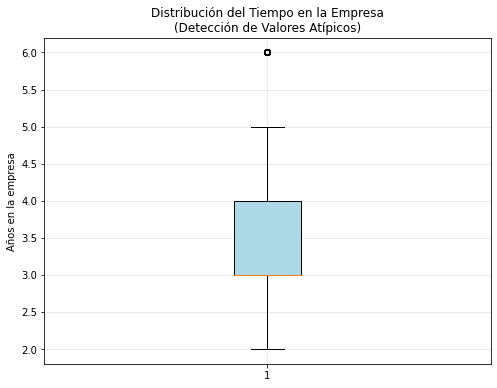

Estadísticas descriptivas de time_spend_company:
count    11709.000000
mean         3.242975
std          1.067812
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: time_spend_company, dtype: float64


In [24]:
# Diagrama de caja específico para detectar valores atípicos en time_spend_company
plt.figure(figsize=(8, 6))
box_plot = plt.boxplot(df2['time_spend_company'], patch_artist=True)
box_plot['boxes'][0].set_facecolor('lightblue')
plt.title('Distribución del Tiempo en la Empresa\n(Detección de Valores Atípicos)')
plt.ylabel('Años en la empresa')
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar estadísticas para identificar valores atípicos
print("Estadísticas descriptivas de time_spend_company:")
print(df2['time_spend_company'].describe())

In [20]:
# Determinar el número de filas que contienen valores atípicos
### YOUR CODE HERE ###



permanencia = 8 satisfaction_level       81
last_evaluation          81
number_project           81
average_montly_hours     81
time_spend_company       81
work_accident            81
left                     81
promotion_last_5years    81
department               81
salary                   81
dtype: int64
permanencia = 7 satisfaction_level       94
last_evaluation          94
number_project           94
average_montly_hours     94
time_spend_company       94
work_accident            94
left                     94
promotion_last_5years    94
department               94
salary                   94
dtype: int64
permanencia = 6 satisfaction_level       542
last_evaluation          542
number_project           542
average_montly_hours     542
time_spend_company       542
work_accident            542
left                     542
promotion_last_5years    542
department               542
salary                   542
dtype: int64


Ciertos tipos de modelos son más sensibles a los valores atípicos que otros. Al construir su modelo, considere si es necesario eliminar los valores atípicos, según el tipo de modelo que decida utilizar.

# PACE: Etapa analizar

- Realizar EDA (analizar relaciones entre variables)

💭
### Reflexione sobre estas preguntas a medida que completa la etapa de análisis.

- ¿Qué observaste sobre las relaciones entre las variables?
- ¿Qué observaste sobre las distribuciones de los datos?
- ¿Qué transformaciones realizaste con tus datos? ¿Por qué tomaste esas decisiones?
- ¿Cuáles son algunos de los propósitos del análisis de datos extraídos (EDA) antes de construir un modelo predictivo?
- ¿Qué recursos utilizas al completar esta etapa? (Asegúrate de incluir los enlaces).
- ¿Tienes alguna consideración ética en esta etapa?

[Haga doble clic para ingresar sus respuestas aquí.]

## Paso 2. Exploración de datos (Continuar con EDA)

Comience por comprender cuántos empleados se fueron y qué porcentaje de todos los empleados representa esta cifra.

In [36]:
# Obtenga números de personas que se fueron y las que se quedaron
### YOUR CODE HERE ###
retenidos = df1[df1['left']==0]['left'].value_counts()
perdidos = df1[df1['left']==1]['left'].value_counts()
print(f"Cantidad de empleados retenidos {retenidos.iloc[0]}")
print(f"Cantidad de empleados perdidos {perdidos.iloc[0]}")
# Obtenga porcentajes de personas que se fueron frente a las que se quedaron
### YOUR CODE HERE ###
print("Porcentajes")
print(df1['left'].value_counts(normalize=True)*100)

Cantidad de empleados retenidos 10000
Cantidad de empleados perdidos 1991
Porcentajes
0    83.39588
1    16.60412
Name: left, dtype: float64


### Visualizaciones de datos

Ahora, examine las variables que le interesan y cree gráficos para visualizar las relaciones entre las variables en los datos.

In [ ]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###


In [ ]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###


In [ ]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###


In [ ]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###


In [ ]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###


In [ ]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###


In [ ]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###


In [ ]:
# Crea un gráfico según sea necesario
### YOUR CODE HERE ###


### Intuición

[¿Qué información puedes obtener de los gráficos que creaste para visualizar los datos? Haz doble clic para ingresar tus respuestas aquí.]

# PACE: Etapa de construcción

- Determinar qué modelos son los más apropiados
- Construir el modelo
- Confirmar los supuestos del modelo
- Evaluar los resultados del modelo para determinar su ajuste a los datos

🔎
## Recordar los supuestos del modelo

**Supuestos del modelo de regresión logística**
- La variable de resultado es categórica
- Las observaciones son independientes entre sí
- Sin multicolinealidad severa entre las variables X
- Sin valores atípicos extremos
- Relación lineal entre cada variable X y el logit de la variable de resultado
- Tamaño de muestra suficientemente grande

💭
### Reflexione sobre estas preguntas a medida que completa la etapa de construcción.

- ¿Observa algo extraño?
- ¿Qué variables independientes eligió para el modelo y por qué?
- ¿Se cumplen todos los supuestos?
- ¿Qué tan bien se ajusta su modelo a los datos?
- ¿Puede mejorarlo? ¿Hay algo que cambiaría del modelo?
- ¿Qué recursos utiliza al completar esta etapa? (Asegúrese de incluir los enlaces).
- ¿Tiene alguna consideración ética en esta etapa?

[Haga doble clic para ingresar sus respuestas aquí.]

## Paso 3. Construcción del modelo, Paso 4. Resultados y evaluación

- Ajustar un modelo que prediga la variable de resultado utilizando dos o más variables independientes.
- Verificar los supuestos del modelo.
- Evaluar el modelo.

### Identificar el tipo de tarea de predicción.

[Haga doble clic para ingresar sus respuestas aquí.]

### Identificar los tipos de modelos más apropiados para esta tarea.

[Haga doble clic para ingresar sus respuestas aquí.]

### Modeling

Agregue tantas celdas como necesite para realizar el proceso de modelado.

In [ ]:
### YOUR CODE HERE ###


# PACE: Etapa ejecutar

- Interpretar el rendimiento y los resultados del modelo
- Compartir las medidas prácticas con las partes interesadas

✏
## Métricas de evaluación de recuperación

- **AUC** es el área bajo la curva ROC; también se considera la probabilidad de que el modelo clasifique un ejemplo positivo aleatorio con mayor probabilidad que uno negativo aleatorio.
- **Precision (Precisión)** mide la proporción de puntos de datos predichos como Verdaderos que realmente lo son; es decir, la proporción de predicciones positivas que son verdaderos positivos.
- **Recall** mide la proporción de puntos de datos predichos como Verdaderos, de todos los puntos de datos que realmente son Verdaderos. En otras palabras, mide la proporción de positivos que se clasifican correctamente.
- **Accuracy (Exactitud)** mide la proporción de puntos de datos que se clasifican correctamente.
- **F1-score (Puntuación F1)** es una suma de la precisión y el recall.

💭
### Reflexione sobre estas preguntas a medida que completa la etapa de ejecución.

- ¿Qué conclusiones clave surgieron de su(s) modelo(s)?
- ¿Qué recomendaciones de negocio propone con base en los modelos creados?
- ¿Qué posibles recomendaciones le haría a su gerente/empresa?
- ¿Cree que su modelo podría mejorarse? ¿Por qué sí o por qué no? ¿Cómo?
- Con base en su conocimiento sobre los datos y los modelos que utilizó, ¿qué otras preguntas podría plantearle al equipo?
- ¿Qué recursos utiliza al completar esta etapa? (Asegúrese de incluir los enlaces).
- ¿Tiene alguna consideración ética en esta etapa?

Haga doble clic para ingresar sus respuestas aquí.

## Paso 4. Resultados y evaluación

- Interpretar el modelo
- Evaluar el rendimiento del modelo mediante métricas
- Preparar resultados, visualizaciones y pasos prácticos para compartir con las partes interesadas

### Resumen de los resultados del modelo.

[Haga doble clic para ingresar su resumen aquí.]

### Conclusión, recomendaciones y próximos pasos

[Haga doble clic para ingresar su conclusión, recomendaciones y próximos pasos aquí.]

**Felicitaciones!** Has completado este laboratorio. Sin embargo, es posible que no veas una marca de verificación verde junto a este elemento en la plataforma de Coursera. Continúa con tu progreso independientemente de la marca de verificación. Simplemente haz clic en el icono de "Guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo se haya registrado.